# CoastWatch OHC Full Archive — VirtualiZarr → Icechunk (na / np / sp)

Builds **three independent Icechunk repositories** — one per region — from the full NOAA
CoastWatch Ocean Heat Content (OHC) archive. Source array bytes stay at CoastWatch HTTPS;
Icechunk stores only byte-range references.

## Regions → repositories

| Region | Repository (Source Cooperative) |
|---|---|
| North Atlantic | `ocean-icechunks/noaa-ohc/na` |
| North Pacific  | `ocean-icechunks/noaa-ohc/np` |
| South Pacific  | `ocean-icechunks/noaa-ohc/sp` |

The three regions have different lat/lon grids, so they cannot share a virtual array —
each region gets its own repository.

## Groups inside every repo

```
/
├── daily/      {region}/2020–2024,               NetCDF-3 Classic, big-endian
├── 14day_v1/   {region}14/2024 → 2025 day 084,    NetCDF-3 Classic, big-endian
└── 14day/      {region}14/2025 day 085 → present, HDF5, little-endian
```

`daily` is the original product (source dir `{region}`); `14day_v1` and `14day` are the
newer `{region}14` product. The `14day_v1`/`14day` split is required because a single
virtual Zarr array cannot mix codec pipelines (NetCDF-3 big-endian vs HDF5 little-endian);
the switch is at 2025 day 084/085 in every region.

Source archive: `https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/`

## Authenticating

```
/home/jovyan/.cargo/bin/source-coop login --duration 1d --port 8400
https://nmfs-openscapes.2i2c.cloud/user/eeholmes/ng-2/proxy/8400/
```

In [ ]:
# Uncomment if needed
# !pip install -q "icechunk>=2.1" "virtualizarr>=2.4" xarray obspec_utils obstore h5netcdf requests matplotlib

In [1]:
import sys
# icechunk_utils.py lives at the repo root (one level up) in the git repo, or
# alongside this notebook when downloaded from Source Cooperative. Jupyter puts
# the notebook's directory on sys.path, so a co-located copy is importable; the
# '..' entry below covers the nested git-repo layout.
sys.path.insert(0, '..')

import math
import re
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import requests
import xarray as xr
import icechunk
import zarr

from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import NetCDF3Parser, HDFParser

from icechunk_utils import open_source_icechunk_repo, get_source_credentials

In [2]:
BROWSER_UA = (
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
    'AppleWebKit/537.36 (KHTML, like Gecko) '
    'Chrome/150.0.0.0 Safari/537.36'
)

COASTWATCH_BASE = 'https://coastwatch.noaa.gov'
OHC_ROOT = f'{COASTWATCH_BASE}/pub/socd2/coastwatch/ocean_heat'

# The three regions. Each becomes its own Icechunk repository.
REGIONS = ['na', 'np', 'sp']

# Within {region}14 the source files switch from NetCDF-3 (big-endian) to HDF5
# (little-endian) at day-of-year 084/085 of 2025 — verified identical for every
# region. Files whose name is <= this are NetCDF-3; later files are HDF5.
def codec_split_filename(region):
    return f'ohc_{region}14QG3_2025_084.nc'

LOADABLE_VARS = ['time', 'latitude', 'longitude']

# -999 is the missing value across all science variables; the NetCDF-3 files
# omit any declaration of it, so readers do not mask it without help.
FILL_VALUE = -999.0
FLOAT_FILL_VARS = ['sst', 'ssha', 'sshaE', 'iso20C', 'iso26C', 'omld', 'ohc']

# Source Cooperative destination. Each region repo lives under this prefix.
SC_BUCKET = 'ocean-icechunks'
SC_PREFIX_BASE = 'noaa-ohc'

def region_prefix(region):
    return f'{SC_PREFIX_BASE}/{region}'

# Group names inside every per-region repo.
GROUP_DAILY = 'daily'      # {region}     original product, NetCDF-3
GROUP_14_V1 = '14day_v1'   # {region}14   NetCDF-3 (big-endian)
GROUP_14    = '14day'      # {region}14   HDF5 (little-endian)

## 1. Confirm HTTP byte-range access

CoastWatch returns 403 to the default `python-requests` User-Agent.
A browser-like UA is required for both the byte-range check and all VirtualiZarr reads.

In [ ]:
test_url = f'{OHC_ROOT}/na14/2024/ohc_na14QG3_2024_015.nc'
r = requests.get(
    test_url,
    headers={'User-Agent': BROWSER_UA, 'Range': 'bytes=0-99'},
    timeout=30,
)
print('status:', r.status_code)
print('accept-ranges:', r.headers.get('Accept-Ranges'))
assert r.status_code == 206, 'Server did not return 206 Partial Content'
print('OK — CoastWatch honors HTTP range requests.')

## 2. Collect source URLs

For each region, scrape the CoastWatch Apache directory listings and split the file list
into the three groups (`daily`, `14day_v1`, `14day`).

In [ ]:
def scrape_nc_urls(dir_url: str, timeout: int = 120, retries: int = 4) -> list[str]:
    # Fetch an Apache mod_autoindex directory listing; return sorted .nc URLs.
    # CoastWatch HTTPS latency is highly variable (a small listing can take 15s+),
    # so use a generous timeout and retry with exponential backoff on failure.
    last_exc = None
    for attempt in range(retries):
        try:
            r = requests.get(
                dir_url.rstrip('/') + '/',
                headers={'User-Agent': BROWSER_UA},
                timeout=timeout,
            )
            r.raise_for_status()
            filenames = sorted(
                fn for fn in re.findall('href="([^"]+)"', r.text)
                if fn.startswith('ohc_') and fn.endswith('.nc')
            )
            return [dir_url.rstrip('/') + '/' + fn for fn in filenames]
        except Exception as exc:
            last_exc = exc
            if attempt < retries - 1:
                backoff = 2 ** attempt
                print(f'  retry {attempt + 1}/{retries - 1} for {dir_url} '
                      f'after {type(exc).__name__} (waiting {backoff}s)')
                time.sleep(backoff)
    raise last_exc


def scrape_years(region_dir: str) -> list[str]:
    # Discover YYYY subdirectories under a region dir, then scrape each for .nc files.
    r = requests.get(region_dir.rstrip('/') + '/',
                     headers={'User-Agent': BROWSER_UA}, timeout=120)
    r.raise_for_status()
    years = sorted(set(re.findall(r'href="(\d{4})/"', r.text)))
    urls = []
    for y in years:
        urls.extend(scrape_nc_urls(f'{region_dir}/{y}'))
    return sorted(urls)


def collect_region_urls(region: str):
    """Return (daily_urls, v1_urls, current_urls) for one region.

    daily   := {region}/*         (original product, NetCDF-3)
    v1      := {region}14/* whose filename <= codec split (NetCDF-3, big-endian)
    current := {region}14/* whose filename >  codec split (HDF5, little-endian)
    """
    daily = scrape_years(f'{OHC_ROOT}/{region}')
    new = scrape_years(f'{OHC_ROOT}/{region}14')
    split = codec_split_filename(region)
    v1 = [u for u in new if Path(u).name <= split]
    current = [u for u in new if Path(u).name > split]
    return daily, v1, current

In [ ]:
REGION_URLS = {}
for region in REGIONS:
    print(f'Scraping {region} / {region}14 ...')
    daily, v1, current = collect_region_urls(region)
    REGION_URLS[region] = {GROUP_DAILY: daily, GROUP_14_V1: v1, GROUP_14: current}

    print(f'  daily   : {len(daily):>4d}  {Path(daily[0]).name} .. {Path(daily[-1]).name}')
    print(f'  14day_v1: {len(v1):>4d}  {Path(v1[0]).name} .. {Path(v1[-1]).name}')
    print(f'  14day   : {len(current):>4d}  {Path(current[0]).name} .. {Path(current[-1]).name}')

    # The codec boundary must be exactly at day 084/085 of 2025 in every region.
    assert Path(v1[-1]).name == f'ohc_{region}14QG3_2025_084.nc', (
        f'{region}: unexpected last 14day_v1 file {Path(v1[-1]).name}')
    assert Path(current[0]).name == f'ohc_{region}14QG3_2025_085.nc', (
        f'{region}: unexpected first 14day file {Path(current[0]).name}')
    print('  codec boundary OK')

## 3. Object store and parsers

One `HTTPStore` and one parser pair are shared across all regions — every source file
lives under `coastwatch.noaa.gov`.

In [ ]:
# Single HTTPStore covering all of coastwatch.noaa.gov
http_store_obj = HTTPStore(
    COASTWATCH_BASE,
    client_options={'user_agent': BROWSER_UA},
)
registry = ObjectStoreRegistry({COASTWATCH_BASE: http_store_obj})

# NetCDF-3 Classic parser — needs User-Agent via reader_options because it
# uses aiohttp/fsspec for its own HTTP reads, not the obspec registry.
nc3_parser = NetCDF3Parser(
    reader_options={
        'storage_options': {
            'client_kwargs': {'headers': {'User-Agent': BROWSER_UA}}
        }
    }
)

# HDF5 parser — picks up the User-Agent from the obspec registry above.
hdf_parser = HDFParser()

### Metadata repair applied per source file

The source archive has three metadata problems that must be corrected before writing.
Only **metadata** is touched — the science arrays (`ohc`, `sst`, ...) stay virtual:

1. **Undeclared missing value.** The NetCDF-3 files use `-999` as the missing value but
   declare no `_FillValue`/`missing_value`, so readers never mask it. We add a CF
   `missing_value` attribute (used instead of `_FillValue` because the Zarr-v3
   `_FillValue` coder expects an encoded form). HDF files already declare it.
2. **Corrupt coordinates.** A few source files ship all-zero `latitude`/`longitude`
   (and all-zero data). We repair coordinates from a trusted per-region grid template so
   every file aligns, and drop the fully-corrupt files entirely (they carry no real data).
3. **NaN-valued attributes.** Some HDF files carry `NaN` global attributes
   (`bounding_box_*`). Icechunk stores Zarr metadata as JSON, which cannot represent
   `NaN`, so those attributes are removed.

The grid template is rebuilt **per region** (regions have different grids), and
`make_repair` binds a `repair` function to that region's template. `open_virtual_mfdataset`
runs it on each file before concatenation.

In [ ]:
def _coords_ok(lat, lon):
    # A valid file has a full monotonic grid; corrupt files are all-zeros.
    return np.unique(lat).size > 1 and np.unique(lon).size > 1


def _drop_nan_attrs(attrs):
    # Icechunk stores Zarr metadata as JSON, which cannot represent NaN.
    for k in list(attrs):
        v = attrs[k]
        if isinstance(v, (float, np.floating)) and math.isnan(float(v)):
            del attrs[k]


def build_grid_template(urls, parser, n_probe=20):
    """Find the first file with a valid coordinate grid and return
    (lat_values, lon_values, lat_attrs, lon_attrs) for that region."""
    for u in urls[:n_probe]:
        try:
            v = open_virtual_dataset(
                url=u, parser=parser, registry=registry,
                loadable_variables=['latitude', 'longitude'], decode_times=False,
            )
        except Exception:
            continue
        lat, lon = v['latitude'].values, v['longitude'].values
        if _coords_ok(lat, lon):
            return (lat.copy(), lon.copy(),
                    dict(v['latitude'].attrs), dict(v['longitude'].attrs))
    raise RuntimeError(f'No good coordinate template in first {n_probe} files.')


def make_repair(lat_template, lon_template, lat_attrs, lon_attrs):
    """Build a per-file repair() bound to one region's trusted grid."""
    def repair(ds):
        _drop_nan_attrs(ds.attrs)
        for name in ds.variables:
            _drop_nan_attrs(ds[name].attrs)

        corrupt = not _coords_ok(ds['latitude'].values, ds['longitude'].values)

        # Force the trusted grid so every file aligns exactly (preserving CF attrs).
        ds = ds.assign_coords(
            latitude=('latitude', lat_template, lat_attrs),
            longitude=('longitude', lon_template, lon_attrs),
        )

        # Declare the missing value where the source omits it, so readers mask -999.
        for v in FLOAT_FILL_VARS:
            if v in ds and 'missing_value' not in ds[v].attrs and '_FillValue' not in ds[v].attrs:
                ds[v].attrs['missing_value'] = np.float32(FILL_VALUE)

        # Fully-corrupt files (all-zero coords == all-zero data) contribute no time
        # steps; the good coords/attrs above still seed the combine via join='override'.
        if corrupt:
            ds = ds.isel(time=slice(0, 0))
        return ds
    return repair

## 4. Icechunk repository config

Every region repo uses the same config: one `VirtualChunkContainer` covering
`coastwatch.noaa.gov`, plus manifest splitting so thousands of time steps don't produce a
single giant manifest at commit time.

In [ ]:
http_prefix = COASTWATCH_BASE + '/'


def build_config():
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=http_prefix,
            store=icechunk.http_store(),
        )
    )
    # Manifest splitting prevents giant single-manifest commits for many time steps.
    config.manifest = icechunk.ManifestConfig(
        splitting=icechunk.ManifestSplittingConfig.from_dict({
            icechunk.ManifestSplitCondition.AnyArray(): {
                icechunk.ManifestSplitDimCondition.DimensionName('time'): 100
            }
        })
    )
    config.manifest.max_concurrent_manifest_fetches_during_commit = 16
    return config

## 5. Write functions

`write_group` opens all files for one group virtually and commits them (skipping if the
group already has data, so the notebook is safe to re-run). `write_region` opens/creates
the region's repo, builds that region's grid template, and writes all three groups.

In [ ]:
def group_step_count(repo, group):
    """Return the number of time steps in a group, or None if it does not exist."""
    sess = repo.readonly_session('main')
    try:
        ds = xr.open_zarr(sess.store, group=group, consolidated=False)
        return len(ds.time)
    except Exception:
        return None


def write_group(repo, group, urls, parser, repair):
    existing = group_step_count(repo, group)
    if existing is not None:
        print(f'  [{group}] already has {existing} time steps — skipping.')
        return

    print(f'  [{group}] opening {len(urls)} files virtually ...')
    t0 = time.perf_counter()

    # data_vars='minimal' concatenates only time-varying arrays; constant metadata
    # (scalar `crs`, `quality_information`) is stored once. join='override' takes the
    # grid from the first (repaired) file without realigning. `repair` fixes coords/attrs.
    vds = open_virtual_mfdataset(
        urls=urls,
        registry=registry,
        parser=parser,
        concat_dim='time',
        combine='nested',
        compat='override',
        coords='minimal',
        data_vars='minimal',
        join='override',
        preprocess=repair,
        loadable_variables=LOADABLE_VARS,
        decode_times=True,
        parallel=ThreadPoolExecutor,
    )
    dropped = len(urls) - vds.sizes['time']
    print(f'  [{group}] opened {vds.sizes["time"]} time steps '
          f'({dropped} corrupt files dropped) in {time.perf_counter() - t0:.1f}s')

    # Single-chunk time coordinate avoids per-timestep metadata overhead.
    vds['time'].encoding['chunks'] = (len(vds['time']),)

    session = repo.writable_session('main')
    vds.vz.to_icechunk(session.store, group=group)
    snap = session.commit(f'Write {group}: {len(vds.time)} time steps')
    print(f'  [{group}] committed {snap}')
    del vds


def write_region(region):
    print(f'\n=== Region {region} -> {region_prefix(region)} ===')
    urls = REGION_URLS[region]

    repo, storage, _creds, time_left = open_source_icechunk_repo(
        bucket=SC_BUCKET,
        prefix=region_prefix(region),
        config=build_config(),
    )
    # Persist our config so anonymous readers (who reopen with no config) pick up the
    # coastwatch.noaa.gov virtual chunk container. Repository.open(config=...) only uses
    # the config for the current session, so save_config() writes it through.
    repo.save_config()

    # Per-region grid template, built from the region's own daily NetCDF-3 files.
    lat, lon, lat_attrs, lon_attrs = build_grid_template(urls[GROUP_DAILY], nc3_parser)
    print(f'  grid: lat {lat[0]}..{lat[-1]} ({lat.size}), '
          f'lon {lon[0]}..{lon[-1]} ({lon.size})')
    repair = make_repair(lat, lon, lat_attrs, lon_attrs)

    write_group(repo, GROUP_DAILY, urls[GROUP_DAILY], nc3_parser, repair)
    write_group(repo, GROUP_14_V1, urls[GROUP_14_V1], nc3_parser, repair)
    write_group(repo, GROUP_14,    urls[GROUP_14],    hdf_parser, repair)
    return repo

## 6. Build all three regions

This is the heavy step: it opens every source file's header (in parallel) and commits the
virtual references for `daily`, `14day_v1`, and `14day` in each region's repo.

In [ ]:
region_repos = {}
for region in REGIONS:
    region_repos[region] = write_region(region)

print('\nAll regions written.')

## 7. Validation

Each cell below reopens the finished repositories directly from Source Cooperative over
HTTPS — independent of the write section above. CoastWatch accepts Icechunk's built-in UA
(`icechunk-rust-x.y.z`) for reads, so no browser header is needed here.

In [3]:
def open_region(region):
    """Open a region's three groups from Source Cooperative (lazy, dask-backed).

    Uses the anonymous public read path — the same URL an external user would use.
    The science arrays live at coastwatch.noaa.gov (outside this Icechunk store), so
    the virtual chunk container is authorized at open time.
    """
    url = f'https://data.source.coop/{SC_BUCKET}/{region_prefix(region)}'
    repo = icechunk.Repository.open(icechunk.http_storage(url))
    auth = {p: icechunk.credentials.HttpAccess
            for p in repo.config.virtual_chunk_containers or []}
    store = repo.reopen(authorize_virtual_chunk_access=auth).readonly_session('main').store
    # chunks={} gives lazy dask arrays (avoids materializing GBs on open).
    return {
        GROUP_DAILY: xr.open_zarr(store, group=GROUP_DAILY, consolidated=False, chunks={}),
        GROUP_14_V1: xr.open_zarr(store, group=GROUP_14_V1, consolidated=False, chunks={}),
        GROUP_14:    xr.open_zarr(store, group=GROUP_14,    consolidated=False, chunks={}),
    }


region_ds = {region: open_region(region) for region in REGIONS}
for region in REGIONS:
    print(f'\n=== {region} ===')
    for name, ds in region_ds[region].items():
        print(f'  {name:9s}: {len(ds.time):>4d} steps  '
              f'{str(ds.time.values[0])[:10]} .. {str(ds.time.values[-1])[:10]}')


=== na ===
  daily    : 1357 steps  2020-04-30 .. 2024-01-18
  14day_v1 :  430 steps  2024-01-15 .. 2025-03-25
  14day    :  506 steps  2025-03-27 .. 2026-08-25

=== np ===
  daily    : 1356 steps  2020-04-30 .. 2024-01-18
  14day_v1 :  390 steps  2024-01-15 .. 2025-03-25
  14day    :  512 steps  2025-03-27 .. 2026-08-25

=== sp ===
  daily    : 1349 steps  2020-04-30 .. 2024-01-18
  14day_v1 :  411 steps  2024-01-15 .. 2025-03-25
  14day    :  513 steps  2025-03-27 .. 2026-08-26


### Validate group boundaries and variable sets

In [4]:
import pandas as pd

# The codec split is at 14day day-of-year 084/085 of 2025 (not a leap year:
# day 084 = Mar 25, day 085 = Mar 26). A boundary file can be dropped if its source
# is corrupt, so check the invariant (v1 on/before day 084, current on/after day 085)
# rather than exact dates. Source timestamps carry a time-of-day, so normalize first.
doy_084 = pd.Timestamp('2025-01-01') + pd.Timedelta(days=83)
doy_085 = pd.Timestamp('2025-01-01') + pd.Timedelta(days=84)

for region in REGIONS:
    g = region_ds[region]
    last_v1 = pd.Timestamp(g[GROUP_14_V1].time.values[-1]).normalize()
    first_cur = pd.Timestamp(g[GROUP_14].time.values[0]).normalize()

    assert last_v1 <= doy_084, (
        f'{region}: 14day_v1 should end on/before {doy_084.date()}, got {last_v1.date()}')
    assert first_cur >= doy_085, (
        f'{region}: 14day should start on/after {doy_085.date()}, got {first_cur.date()}')
    assert g[GROUP_14_V1].time.values[-1] < g[GROUP_14].time.values[0], (
        f'{region}: 14day_v1 must end before 14day starts')

    # quality_flag is a 14day-product variable, absent from the daily product.
    assert 'quality_flag' not in g[GROUP_DAILY].data_vars, f'{region}: quality_flag in daily'
    assert 'quality_flag' in g[GROUP_14_V1].data_vars, f'{region}: quality_flag missing from 14day_v1'
    assert 'quality_flag' in g[GROUP_14].data_vars, f'{region}: quality_flag missing from 14day'

    print(f'{region}: boundary + variable-set assertions passed')
    print(f'   daily vars   : {sorted(g[GROUP_DAILY].data_vars)}')
    print(f'   14day_v1 vars: {sorted(g[GROUP_14_V1].data_vars)}')
    print(f'   14day vars   : {sorted(g[GROUP_14].data_vars)}')

na: boundary + variable-set assertions passed
   daily vars   : ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'ssha', 'sshaE', 'sst']
   14day_v1 vars: ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'quality_flag', 'quality_information', 'ssha', 'sshaE', 'sst']
   14day vars   : ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'quality_flag', 'ssha', 'sshaE', 'sst']
np: boundary + variable-set assertions passed
   daily vars   : ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'ssha', 'sshaE', 'sst']
   14day_v1 vars: ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'quality_flag', 'quality_information', 'ssha', 'sshaE', 'sst']
   14day vars   : ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'quality_flag', 'ssha', 'sshaE', 'sst']
sp: boundary + variable-set assertions passed
   daily vars   : ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 'ssha', 'sshaE', 'sst']
   14day_v1 vars: ['crs', 'iso20C', 'iso26C', 'landmask', 'ohc', 'omld', 

### Validate codec homogeneity

Confirm each group's underlying files have a uniform codec. The NetCDF-3 magic number is
`CDF`; HDF5 is `\x89HDF`. Checking the boundary files is enough to prove the split is clean.

In [ ]:
def file_format(url):
    r = requests.get(url, headers={'User-Agent': BROWSER_UA, 'Range': 'bytes=0-7'},
                     timeout=60)
    b = r.content
    if b[:3] == b'CDF':
        return 'nc3'
    if b[:4] == b'\x89HDF':
        return 'hdf5'
    return 'other:' + b[:4].hex()

for region in REGIONS:
    u = REGION_URLS[region]
    daily_last = file_format(u[GROUP_DAILY][-1])
    v1_last = file_format(u[GROUP_14_V1][-1])
    cur_first = file_format(u[GROUP_14][0])
    print(f'{region}: daily(last)={daily_last}  14day_v1(last)={v1_last}  14day(first)={cur_first}')
    assert daily_last == 'nc3', f'{region}: daily should be NetCDF-3'
    assert v1_last == 'nc3', f'{region}: 14day_v1 should be NetCDF-3'
    assert cur_first == 'hdf5', f'{region}: 14day should be HDF5'
print('\nCodec homogeneity verified.')

### Plot OHC — first daily time step per region

Source OHC data use `-999` as the fill value; the `missing_value` attribute added during
the write masks it to `NaN` automatically, so only real data appears.

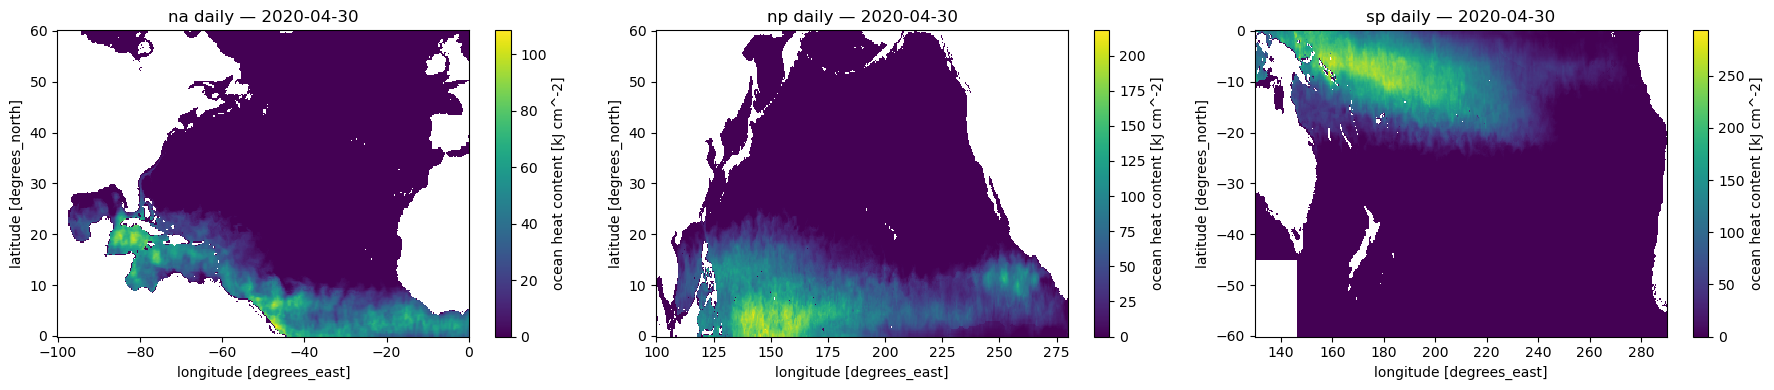

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(REGIONS), figsize=(6 * len(REGIONS), 4))
for ax, region in zip(axes, REGIONS):
    ds = region_ds[region][GROUP_DAILY]
    t0 = ds.time.values[0]
    ds['ohc'].sel(time=t0).load().plot(
        ax=ax, x='longitude', y='latitude', cmap='viridis', add_colorbar=True,
    )
    ax.set_title(f'{region} daily — {str(t0)[:10]}')

plt.tight_layout()
plt.show()

## 8. Upload README and this notebook

Uploads the master README and this notebook to the `noaa-ohc/` root on Source
Cooperative (the per-region Icechunk repos live in the `na/`, `np/`, `sp/` subfolders).

In [ ]:
from icechunk_utils import get_source_credentials

# Refresh Source Cooperative credentials via the source-coop CLI.
source_creds, _ = get_source_credentials()

import boto3
s3 = boto3.client(
    's3',
    endpoint_url=source_creds['endpoint_url'],
    region_name=source_creds['region_name'],
    aws_access_key_id=source_creds['aws_access_key_id'],
    aws_secret_access_key=source_creds['aws_secret_access_key'],
    aws_session_token=source_creds.get('aws_session_token'),
)

files_to_upload = [
    'README.md',
    'ocean-heat-production-sc.ipynb',
]

for local_file in files_to_upload:
    path = Path(local_file)
    if not path.is_file():
        raise FileNotFoundError(f'File not found: {path}')
    key = f'{SC_PREFIX_BASE}/{path.name}'
    s3.upload_file(Filename=str(path), Bucket=SC_BUCKET, Key=key)
    print(f'Uploaded {path} -> s3://{SC_BUCKET}/{key}')

## Troubleshooting — clear the entire noaa-ohc prefix

Deletes **all** objects under `noaa-ohc` (every region repo plus the docs).
Source Cooperative's S3 gateway does not support batch `DeleteObjects`, so this deletes
one object at a time. Guarded by `RUN_CLEAR` so it never runs by accident.

In [ ]:
RUN_CLEAR = False  # set True to delete ALL objects under noaa-ohc

if RUN_CLEAR:
    from icechunk_utils import get_source_credentials
    import boto3

    source_creds, _ = get_source_credentials()
    s3 = boto3.client(
        's3',
        endpoint_url=source_creds['endpoint_url'],
        region_name=source_creds['region_name'],
        aws_access_key_id=source_creds['aws_access_key_id'],
        aws_secret_access_key=source_creds['aws_secret_access_key'],
        aws_session_token=source_creds.get('aws_session_token'),
    )
    paginator = s3.get_paginator('list_objects_v2')
    n = 0
    for page in paginator.paginate(Bucket=SC_BUCKET, Prefix=SC_PREFIX_BASE + '/'):
        for obj in page.get('Contents', []):
            s3.delete_object(Bucket=SC_BUCKET, Key=obj['Key'])
            n += 1
            if n % 500 == 0:
                print(f'  deleted {n} ...')
    print(f'Deleted {n} objects under {SC_PREFIX_BASE}/')
else:
    print('RUN_CLEAR is False — no objects deleted.')